# 04 - Nonlinear circuits: the harmonic-balance path

When a netlist contains a nonlinear device (a diode), DPSpice does not use the
linear IDP path - it auto-selects **harmonic balance (HB)**, solving for a set
of `K` harmonics with a Newton iteration. This notebook walks the half-wave
rectifier, reads off the physically meaningful **conduction angle**, and shows
how a smoothing capacitor narrows it.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import dpspice
from dpspice.plotting import use_style, PALETTE, table
use_style()

res = dpspice.load(dpspice.example_text("rectifier_halfwave.sp")).run()
print("solver            :", res.solver)
print("harmonics K       :", res.K)
print("converged         :", res.converged)
print("conduction angle  : %.2f deg" % res.summary["conduction_angle_deg"])


solver            : hb
harmonics K       : 20
converged         : True
conduction angle  : 173.67 deg


## Input vs rectified output

The diode conducts only on part of each cycle; the output node follows the input
while conducting and decays otherwise.

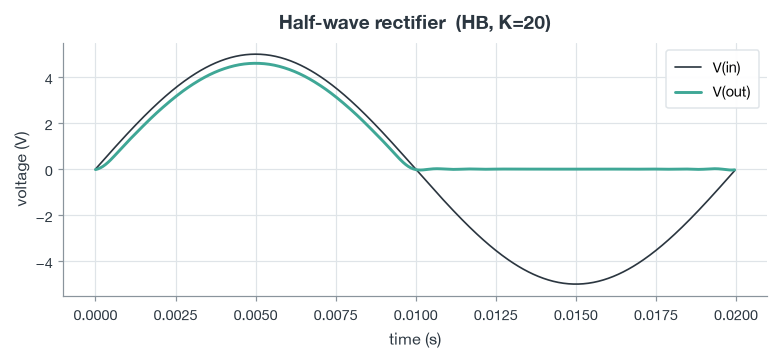

In [2]:
def wave(result, name):
    w = next(w for w in result.waveforms if w.name.lower() == name.lower())
    return np.asarray(w.t, float), np.asarray(w.v, float)

t_in, v_in   = wave(res, "v(in)")
t_out, v_out = wave(res, "v(out)")

fig, ax = plt.subplots()
ax.plot(t_in, v_in, color=PALETTE["ink"], lw=1.1, label="V(in)")
ax.plot(t_out, v_out, color=PALETTE["teal"], lw=1.9, label="V(out)")
ax.set_xlabel("time (s)"); ax.set_ylabel("voltage (V)")
ax.set_title("Half-wave rectifier  (HB, K=%d)" % res.K)
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


## A smoothing capacitor narrows the conduction angle

The `rectifier_rc` example adds an output capacitor. The diode now conducts only
near the peak (it tops the cap up), so the conduction angle shrinks sharply -
and DPSpice reports that directly from the HB solution.

rectifier_halfwave.sp  solver=hb K=20  conduction=173.67 deg  V(out) ripple=4.641
rectifier_rc.sp        solver=hb K=20  conduction=47.11 deg  V(out) ripple=0.764


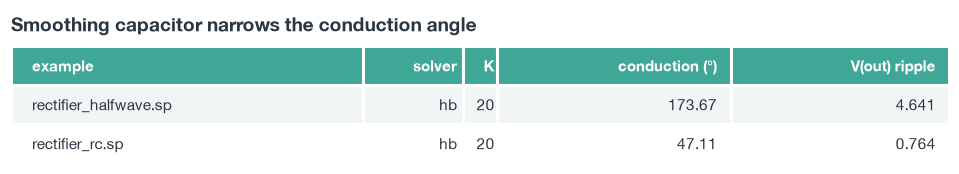

In [3]:
cases = ["rectifier_halfwave.sp", "rectifier_rc.sp"]
summary = []
for name in cases:
    r = dpspice.load(dpspice.example_text(name)).run()
    s = r.summary
    summary.append((name, r.solver, r.K, s["conduction_angle_deg"],
                    s["nodes"]["V(out)"]["ripple"]))
    print("%-22s solver=%s K=%s  conduction=%.2f deg  V(out) ripple=%.3f" % (
        name, r.solver, r.K, s["conduction_angle_deg"], s["nodes"]["V(out)"]["ripple"]))

table(
    ["example", "solver", "K", "conduction (°)", "V(out) ripple"],
    [(n, sv, str(k), "%.2f" % ca, "%.3f" % rp) for (n, sv, k, ca, rp) in summary],
    title="Smoothing capacitor narrows the conduction angle",
)
plt.show()


The capacitor cuts the conduction angle from a wide half-cycle to a narrow
peak-charging window - the classic peak-detector behaviour, recovered here
without any manual mode selection.